In [ ]:
import os

### to export libLLVM path
os.environ['DRJIT_LIBLLVM_PATH'] = "/home/aizi0357/environments/sionna_v0/lib/libLLVM-20.so"
os.environ["LD_LIBRARY_PATH"] = "$LD_LIBRARY_PATH:/home/aizi0357/environments/sionna_v0/lib/"

gpu_num = "" # Use "" to use the CPU
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import sionna

resolution = [480,320] # increase for higher quality of renderings

# Allows to exit cell execution in Jupyter
class ExitCell(Exception):
    def _render_traceback_(self):
        pass

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("gpus:", gpus)
print(f"Using GPU {gpu_num}")
if gpu_num and gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

tf.get_logger().setLevel('ERROR')

tf.random.set_seed(1) # Set global random seed for reproducibility

import matplotlib.pyplot as plt
import numpy as np
import time

# Import Sionna RT components
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, Camera

E0000 00:00:1774964251.660411 3868871 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774964251.664488 3868871 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774964251.674254 3868871 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774964251.674264 3868871 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774964251.674266 3868871 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774964251.674268 3868871 computation_placer.cc:177] computation placer already registered. Please check linka

gpus: []
Using GPU 


In [2]:
tx_dist = 100.0  # far-field 
num_points = 360

dtype = tf.complex128
rdtype = tf.float64

scene = load_scene(sionna.rt.scene.sphere, dtype)

num_edges: tf.Tensor(0, shape=(), dtype=int32)
num_wedges: 120


In [3]:
sionna.rt.scene.sphere, #sionna.rt.scene.cylinder_12

('/home/aizi0357/projects/sionna_reflectivity_public/sionna/rt/scenes/sphere/sphere.xml',)

In [4]:
def get_circle_points(theta_arr, p1, p2):
    res = np.zeros((len(theta_arr), 3))
    res[:, 0] = p1[0] * np.cos(theta_arr) + p2[0] * np.sin(theta_arr)
    res[:, 1] = p1[1] * np.cos(theta_arr) + p2[1] * np.sin(theta_arr)
    res[:, 2] = p1[2] * np.cos(theta_arr) + p2[2] * np.sin(theta_arr)

    return res

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V",
                             dtype=dtype)

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V",
                             dtype=dtype)

fc = 2e9 
lamda = 3e8 / fc

source_point = np.array([-tx_dist, 0.0, 0.01])

circle_radius = 20.0 * lamda 

theta_arr = np.linspace(0.0, 2*np.pi, num_points, endpoint=False)
circle_p1 = np.array([-1, 0, 0]) * circle_radius
circle_p2 = np.array([0, 1, 0])  * circle_radius
receive_points = get_circle_points(theta_arr, circle_p1, circle_p2)

scene.remove("tx")
for i in range(len(receive_points)):
    scene.remove(f"rx_{i}")


tx = Transmitter(name="tx", position=source_point, dtype=dtype) 
scene.add(tx)
for i in range(len(receive_points)): 
    rx = Receiver(name=f"rx_{i}", position=receive_points[i], dtype=dtype)
    scene.add(rx)

scene.frequency = fc
scene.synthetic_array = True 

coef = (4 * np.pi * tx_dist)

tf.reduce_mean(scene._solver_paths._wedges_length) / lamda  # average edge length in wavelengths

<tf.Tensor: shape=(), dtype=float64, numpy=7.453229060893212>

In [5]:
from sionna.rt.objects_geometry import ObjectsGeometry

obj_names = list(scene.objects.keys())
obj_geom = ObjectsGeometry(scene._solver_paths)

obj_geom.is_table_gfi = True
obj_geom.is_vertex_diffraction = True

obj_geom.init_objects(obj_names)

scene._solver_paths.vertex_diffraction.set_objects_geometry(obj_geom)
scene._solver_paths.double_diffraction.set_objects_geometry(obj_geom)

num vertices: 42


In [6]:
def get_field_los_full(tx_pos, rx_poses):
    dist = np.linalg.norm(tx_pos - rx_poses, axis=1)
    field = 1.0 / dist / (4 * 3.141592653589793) * lamda 
    return field

field_los_full = get_field_los_full(source_point, receive_points)

paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = False,
                            diffraction = False,
                            vertex_diffraction = False)

a, tau = paths.cir()
path_amplitudes = a[0,:,0,0,0,:,0]
receiver_amplitudes_los = np.abs(np.sum(path_amplitudes, axis=1)) #/ lamda

los_line = np.where(receiver_amplitudes_los <= 1e-6)[0][0]
field_los_full = np.where(receiver_amplitudes_los <= 0.0, field_los_full, receiver_amplitudes_los) + 1e-8
los_line

np.int64(140)

Text(0.5, 1.0, 'RT')

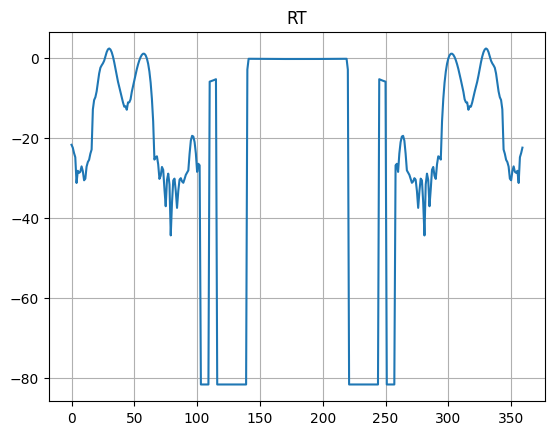

In [7]:
paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = False)

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]

tmp1 = np.sum(path_amplitudes, axis=1) - field_los_full
    
receiver_amplitudes_no = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_no))
plt.grid()
plt.title("RT")

/home/aizi0357/projects/sionna_reflectivity_public/sionna/rt/double_diffraction.py:2963: RuntimeWarning: divide by zero encountered in divide
  spreading_factor = np.sqrt(r1) / (np.sqrt(l * r2) * np.sqrt(r1 + l + r2))


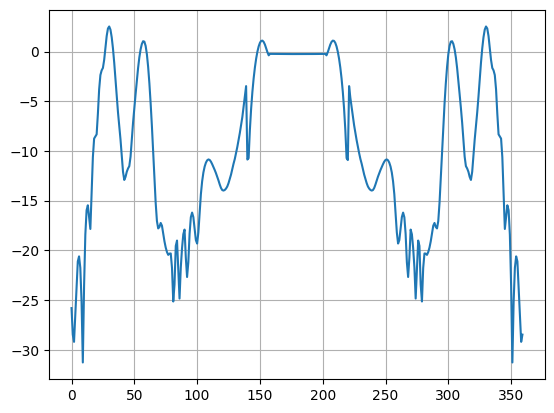

In [8]:
scene._solver_paths.double_diffraction.is_wedge_vertex = False
scene._solver_paths.double_diffraction.is_vertex_wedge = False

paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = True,
                            double_diffraction = True)

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]

tmp1 = np.sum(path_amplitudes, axis=1) - field_los_full
    
receiver_amplitudes_vd = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_vd))
plt.grid()
# plt.title("RT+VD+DD")

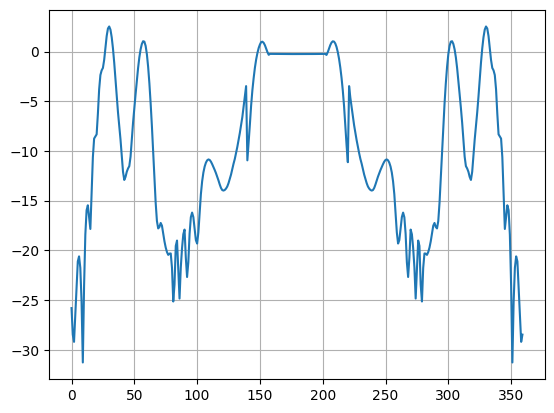

In [9]:
scene._solver_paths.double_diffraction.is_wedge_vertex = True
scene._solver_paths.double_diffraction.is_vertex_wedge = True
scene._solver_paths.double_diffraction.is_vw_reversed_compute_fields = True
scene._solver_paths.double_diffraction.close_2_transition_eps = 0.9

paths = scene.compute_paths(max_depth=1,
                            method="exhaustive",
                            num_samples=1e6,
                            los = True,
                            reflection = True,
                            diffraction = True,
                            vertex_diffraction = True,
                            double_diffraction = True)

a, tau = paths.cir()
#a.shape   # [batch_size, num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths, num_time_steps]

nans_bool = tf.math.is_nan(tf.math.real(a)) 
a = tf.where(nans_bool, tf.zeros_like(a), a)

path_amplitudes = a[0,:,0,0,0,:,0]

tmp1 = np.sum(path_amplitudes, axis=1) - field_los_full
    
receiver_amplitudes_vd = np.abs(tmp1) / lamda

plt.plot(20*np.log10(coef*receiver_amplitudes_vd))
plt.grid()
# plt.title("RT+VD+DD")

Text(0.5, 0, 'Azimuth [deg]')

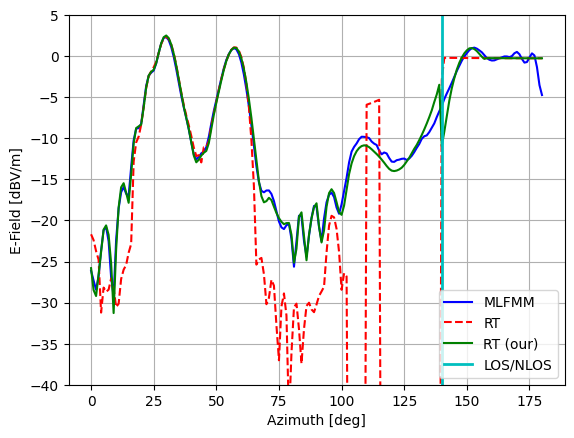

In [10]:
# EM sim for nu == 2 and nu == 15
if num_points == 360:
    sparse = 2
elif num_points == 720:
    sparse = 1
    
def get_em(sparse=1):
    filename_em = "./mlfmm_data/sphere/sphere_mlfmm.txt"

    res = _get_em_2(filename_em)

    if sparse == 1:  # for 720 points
        return res
    elif sparse == 2:  # for 360 points
        return res[::2]


def _get_em_2(filename_james):
    field_em_db = []
    with open(filename_james) as f:
        for i, line in enumerate(f):
            if i == 0 or i == 1:
                continue

            a, b, c = line.split()
            b = float(b)
            #c = float(c)

            field_em_db.append(b)    
        
        field_em_db = np.array(field_em_db[:720])

    return field_em_db

field_em = get_em(sparse=2)

plt.plot(field_em[:num_points//2+1], c='b', label="MLFMM")
plt.plot(20*np.log10(coef*receiver_amplitudes_no[:num_points//2+1]), linestyle='--', c='r', label="RT")
plt.plot(20*np.log10(coef*receiver_amplitudes_vd[:num_points//2+1]), c='green', label="RT (our)")

plt.axvline(x=theta_arr[los_line]*57.3, c='c', linewidth=2.0, label="LOS/NLOS")
plt.ylim([-40, 5])
plt.grid()
plt.legend()
plt.ylabel("E-Field [dBV/m]")
plt.xlabel("Azimuth [deg]")